In this notebook, we demonstrate the fundamentals of an FDN reverb, based on:

- Jot, J.-M., "Efficient Models for Reverberation and Distance Rendering in Auditory Displays," Proc. of the 2001 Int. Conf. on Auditory Display (ICAD).
- Stautner, J., and Puckette, M. (1982). "Designing multi-channel reverberators." Computer Music Journal, 6(1), 52–65.

FDNs offer a powerful, flexible way to model artificial reverberation using delay lines interconnected by a feedback matrix.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

# Sampling parameters
fs = 48000            # Sample rate (Hz)
T = 2.0               # Total reverb time (seconds)
N = int(T * fs)       # Total number of samples

# Number of delay lines
num_delays = 4


In [2]:
# Delay lengths in samples - using mutually prime numbers to avoid overlap
delay_lengths = [4799, 4999, 5399, 5801]  # samples

# Delay buffers for each delay line
states = [np.zeros(l) for l in delay_lengths]
indices = np.zeros(num_delays, dtype=int)


In [3]:
from scipy.linalg import hadamard

def unitary_matrix(n):
    H = hadamard(n)
    return H[:n, :n] / np.sqrt(n)

A = unitary_matrix(num_delays)


-----

# Impulse Response

In [4]:
x = np.zeros(N)
x[0] = 1.0  # Dirac impulse at t = 0

# Output buffer
y = np.zeros(N)


In [5]:
for n in range(N):
    # Read from each delay line
    outs = np.array([states[i][indices[i]] for i in range(num_delays)])
    
    # Mix via feedback matrix
    feedback = A @ outs
    
    # Feed input and feedback back into delay lines
    for i in range(num_delays):
        input_signal = x[n] if n == 0 else 0
        states[i][indices[i]] = input_signal + 0.7 * feedback[i]  # 0.7 = feedback gain

    # Output: sum of all delay outputs
    y[n] = np.sum(outs)

    # Advance circular buffer positions
    indices = (indices + 1) % np.array(delay_lengths)


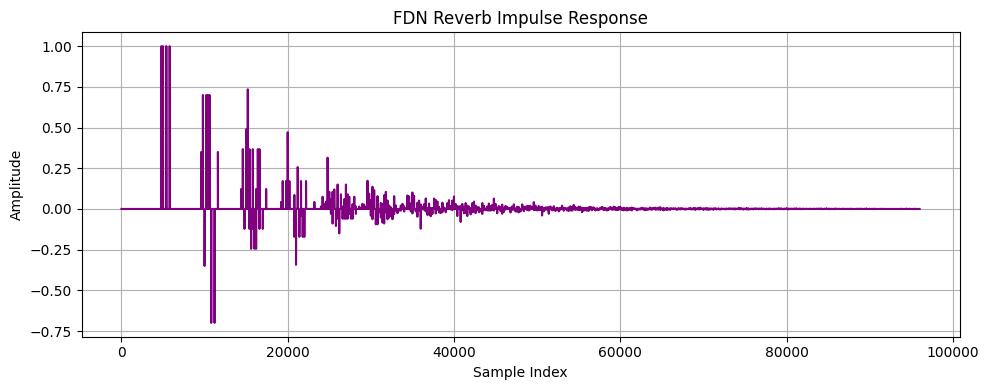

In [6]:
# Normalize output
y /= np.max(np.abs(y))

plt.figure(figsize=(10, 4))
plt.plot(y, color='purple')
plt.title("FDN Reverb Impulse Response")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
from IPython.display import Audio

# Normalize output to the appropriate audio range
y_normalized = np.int16(y / np.max(np.abs(y)) * 32767)

# Play the audio directly from the output array
Audio(y_normalized, rate=fs)

In [20]:
# Delay lengths in samples - using mutually prime numbers to avoid overlap
delay_lengths = [4799, 4999, 5399, 5801]  # samples

# Delay buffers for each delay line
states = [np.zeros(l) for l in delay_lengths]
indices = np.zeros(num_delays, dtype=int)


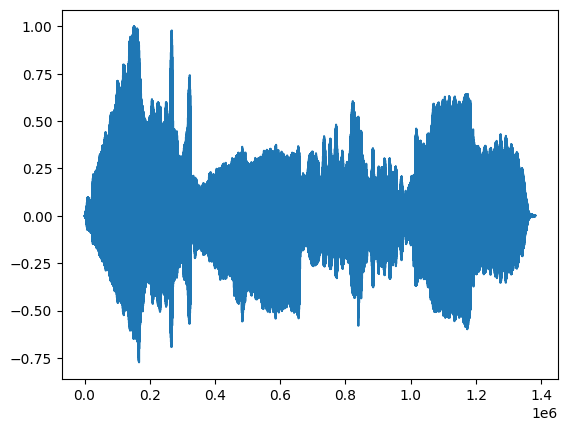

In [21]:

import urllib.request
from scipy.io import wavfile
import io


dry_url = "https://ringbuffer.org/download/audio/violin/Solo_DPA_02.wav"
response = urllib.request.urlopen(dry_url)
audio_data = response.read()
        
with io.BytesIO(audio_data) as temp_file:        
    dry_sr, dry = wavfile.read(temp_file)


# Normalize
x = dry / np.max(np.abs(dry))
#dry = dry / np.max(np.abs(dry))

plt.plot(x)


In [8]:
# Main FDN processing loop (using sine wave as input)
N = len(x)
y = np.zeros(N)

for n in range(N):
    # Read from each delay line
    outs = np.array([states[i][indices[i]] for i in range(num_delays)])
    
    # Mix via feedback matrix
    feedback = A @ outs
    
    # Feed input and feedback back into delay lines
    for i in range(num_delays):
        input_signal = x[n] if n == 0 else 0
        states[i][indices[i]] = input_signal + 0.7 * feedback[i]  # 0.7 = feedback gain

    # Output: sum of all delay outputs
    y[n] = np.sum(outs)

    # Advance circular buffer positions
    indices = (indices + 1) % np.array(delay_lengths)


In [9]:
from IPython.display import Audio

# Normalize the output for playback
y_normalized = np.int16(y / np.max(np.abs(y)) * 32767)

# Play the generated audio directly from the output array (sine wave input + FDN reverb)
Audio(y_normalized, rate=fs)


96000